In [ ]:
# transfer learning notes kept lightweight for portfolio
!pip install kaggle

In [ ]:
!mkdir -p /root/.kaggle
!scp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d phucthaiv02/butterfly-image-classification

Dataset URL: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification
License(s): CC0-1.0


In [ ]:
!rm -rf /content/butterfly
!unzip butterfly-image-classification.zip -d butterfly

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: butterfly/train/Image_2348.jpg  
  inflating: butterfly/train/Image_2349.jpg  
  inflating: butterfly/train/Image_235.jpg  
  inflating: butterfly/train/Image_2350.jpg  
  inflating: butterfly/train/Image_2351.jpg  
  inflating: butterfly/train/Image_2352.jpg  
  inflating: butterfly/train/Image_2353.jpg  
  inflating: butterfly/train/Image_2354.jpg  
  inflating: butterfly/train/Image_2355.jpg  
  inflating: butterfly/train/Image_2356.jpg  
  inflating: butterfly/train/Image_2357.jpg  
  inflating: butterfly/train/Image_2358.jpg  
  inflating: butterfly/train/Image_2359.jpg  
  inflating: butterfly/train/Image_236.jpg  
  inflating: butterfly/train/Image_2360.jpg  
  inflating: butterfly/train/Image_2361.jpg  
  inflating: butterfly/train/Image_2362.jpg  
  inflating: butterfly/train/Image_2363.jpg  
  inflating: butterfly/train/Image_2364.jpg  
  inflating: butterfly/train/Image_2365.jpg  
  inflating: b

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
data = pd.read_csv("butterfly/Training_set.csv")

In [ ]:
print("Number of training:",data.shape[0])
print("Columns: ", data.columns)

Number of training: 6499
Columns:  Index(['filename', 'label'], dtype='object')


In [ ]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  6499 non-null   object
 1   label     6499 non-null   object
dtypes: object(2)
memory usage: 101.7+ KB


,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [ ]:
def to_lower(col):
    return col.lower()


In [ ]:
data["label"] = data["label"].apply(to_lower)

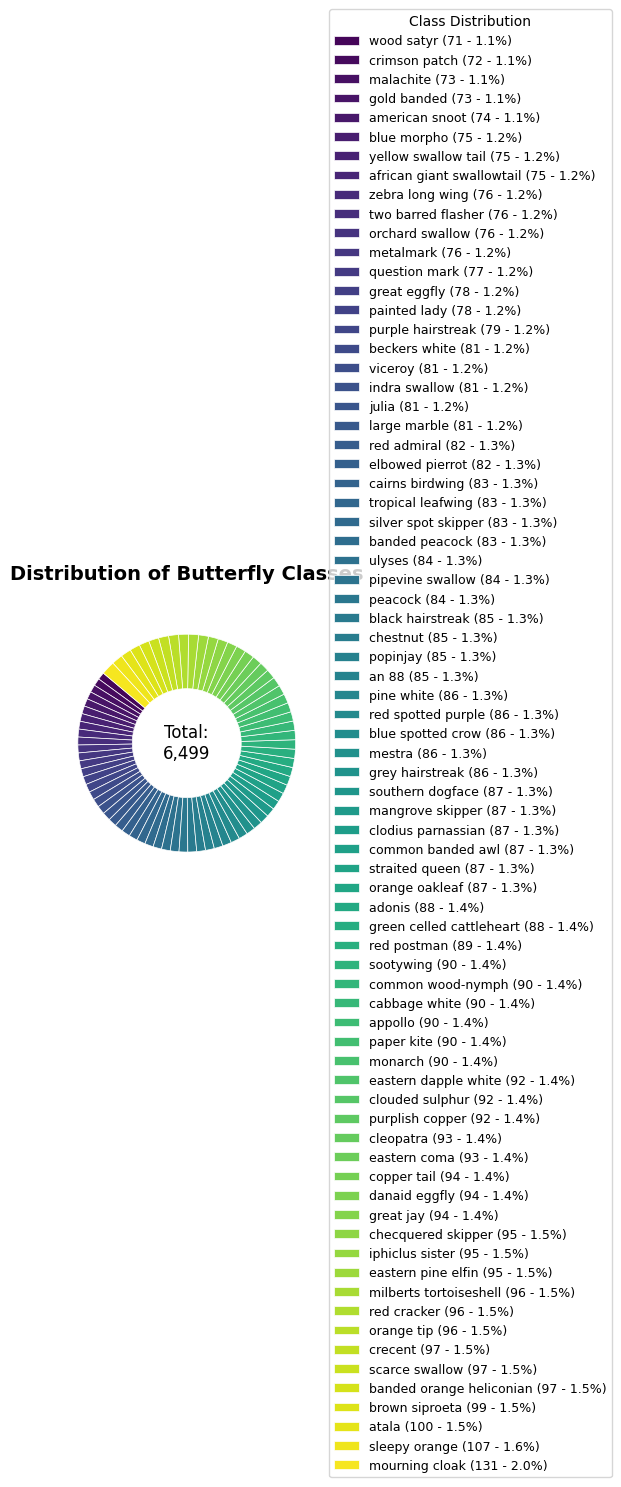

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Подготовка данных
class_counts = data['label'].value_counts().sort_values(ascending=True)
colors = sns.color_palette("viridis", len(class_counts))
percentages = (class_counts / class_counts.sum()) * 100

plt.figure(figsize=(12, 10))
ax = plt.subplot(111)

# Круговая диаграмма
wedges, texts = ax.pie(
    class_counts,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.5, edgecolor='w', linewidth=0.5)  # Добавляем отступы между секторами
)

# Настройка легенды
legend_labels = [f"{label} ({count:,} - {pct:.1f}%)"
                for label, count, pct in zip(class_counts.index, class_counts, percentages)]

plt.legend(
    wedges,
    legend_labels,
    title="Class Distribution",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

# Добавление заголовка
plt.title('Distribution of Butterfly Classes', pad=20, fontsize=14, fontweight='bold')

# Добавление информации об общем количестве в центре
centre_circle = plt.Circle((0,0), 0.3, color='white')
ax.add_artist(centre_circle)
plt.text(0, 0, f"Total:\n{sum(class_counts):,}",
         ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

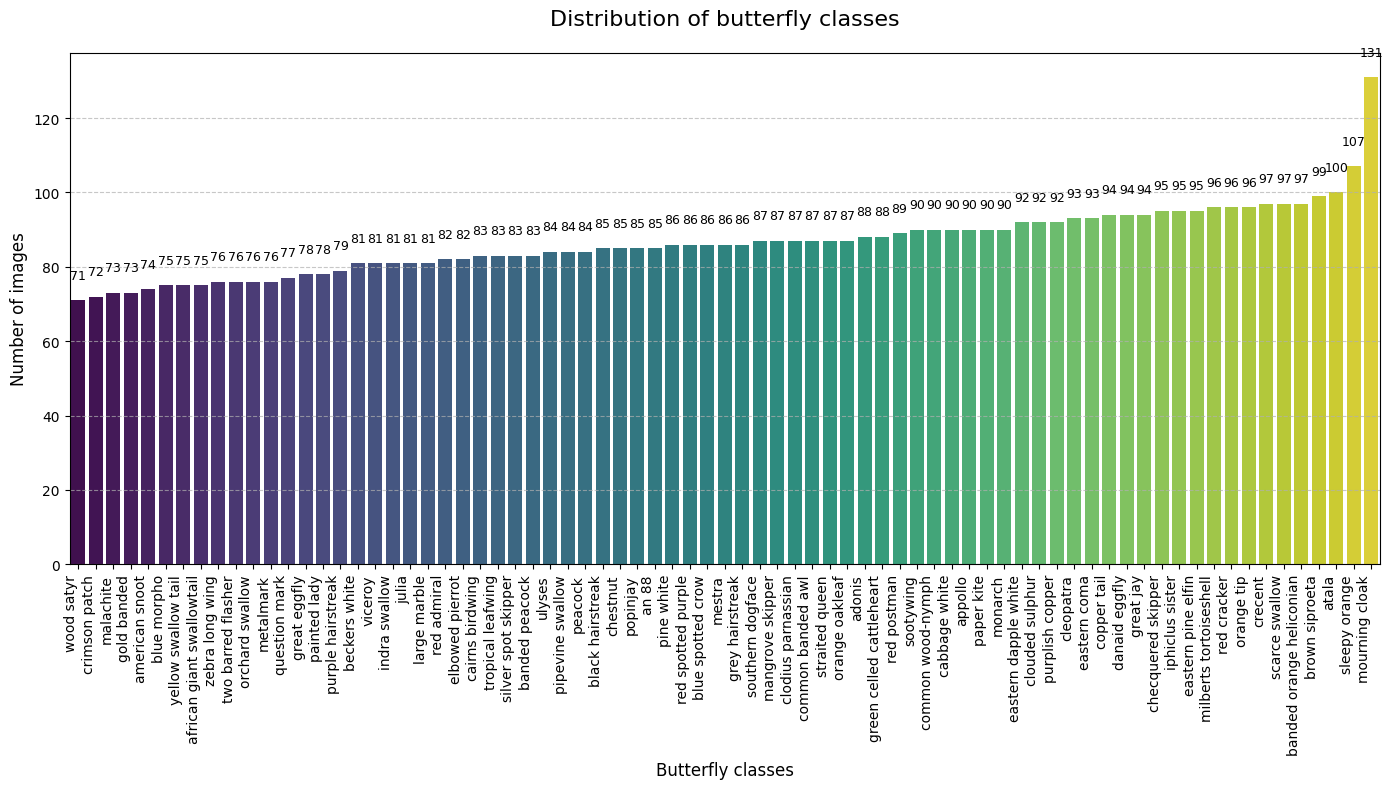

In [ ]:
# Импорт необходимых библиотек
import matplotlib.pyplot as plt
import seaborn as sns

# Установка размера фигуры (14 дюймов по ширине, 8 дюймов по высоте)
plt.figure(figsize=(14, 8))

# Создание столбчатой диаграммы с использованием seaborn
sns.barplot(
    x=class_counts.index,  # Категории по оси X (названия классов бабочек)
    y=class_counts.values,  # Значения по оси Y (количество изображений)
    hue=class_counts.index,  # Цвета столбцов по категориям
    palette="viridis",      # Цветовая палитра (оттенки сине-зеленого)
    legend=False           # Отключаем легенду (так как категорий много)
)

# Настройка заголовка и подписей осей
plt.title('Distribution of butterfly classes', fontsize=16, pad=20)  # pad - отступ заголовка
plt.xlabel('Butterfly classes', fontsize=12)
plt.ylabel('Number of images', fontsize=12)

# Настройка меток на оси X:
# rotation=90 - поворот подписей на 90 градусов (вертикально)
# ha='right' - выравнивание по правому краю (для лучшей читаемости)
plt.xticks(
    rotation=90,
    ha='right',
    fontsize=10  # Размер шрифта подписей
)

# Добавление сетки для лучшей читаемости значений
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Настройка отступов, чтобы все элементы поместились
plt.tight_layout()

# Добавление аннотаций с количеством изображений над каждым столбцом
for i, count in enumerate(class_counts.values):
    plt.text(
        i,                      # Позиция по X
        count + 5,              # Позиция по Y (немного выше столбца)
        str(count),             # Текст (количество изображений)
        ha='center',            # Горизонтальное выравнивание по центру
        va='bottom',            # Вертикальное выравнивание по низу
        fontsize=9              # Размер шрифта
    )

# Отображение графика
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Путь к директории с изображениями
image_dir = "/content/butterfly/train"

# Выбор случайных 30 изображений (с фиксированным random_state для воспроизводимости)
sample_img = data.sample(30, random_state=42)

# Создание сетки 5x6 для отображения изображений
fig, axes = plt.subplots(5, 6, figsize=(20, 20))  # Увеличен размер фигуры
fig.suptitle('Sample Butterfly Images from Dataset', fontsize=24, y=1.02)  # Главный заголовок

# Удаление лишних осей, если изображений меньше 30
for ax in axes.flatten()[len(sample_img):]:
    ax.axis('off')
    ax.remove()  # Полностью удаляем пустые subplots

# Перебор выбранных изображений
for i, (index, row) in enumerate(sample_img.iterrows()):
    try:
        # Загрузка и предобработка изображения
        img_path = os.path.join(image_dir, row['filename'])
        img = load_img(img_path, target_size=(224, 224))  # Увеличен размер для лучшего качества
        img_array = img_to_array(img) / 255.0  # Нормализация к [0,1]

        # Отображение изображения
        ax = axes[i // 6, i % 6]
        ax.imshow(img_array)

        # Настройка заголовка с классом
        ax.set_title(
            f"Class: {row['label']}",
            fontsize=10,  # Уменьшен размер шрифта
            pad=5,       # Отступ заголовка
            color='black',
            backgroundcolor='white',
            alpha=0.7
        )

        # Удаление осей
        ax.axis('off')

    except Exception as e:
        print(f"Error loading image {row['filename']}: {str(e)}")
        axes[i // 6, i % 6].axis('off')  # Скрываем subplot если возникла ошибка

# Настройка отступов и отображение
plt.tight_layout()
plt.subplots_adjust(
    wspace=0.1,  # Горизонтальный отступ между изображениями
    hspace=0.3   # Вертикальный отступ между изображениями
)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import random

In [ ]:
def check_gpu():
    if tf.config.list_physical_devices('GPU'):
        print("GPU is available")
    else:
        print("No GPU found, using CPU")

check_gpu()

GPU is available


In [ ]:
# ======================
# 1. ПАРАМЕТРЫ И НАСТРОЙКИ
# ======================
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 50
RANDOM_SEED = 42
DATA_DIR = '/content/butterfly/train'

In [ ]:
# ======================
# 2. ПОДГОТОВКА ДАННЫХ
# ======================
# Загрузка и разделение данных
train_data, val_data = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED, stratify=data['label'])

# Создание генераторов данных
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=DATA_DIR,
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory=DATA_DIR,
    x_col='filename',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.


In [ ]:
# ======================
# 3. СОЗДАНИЕ МОДЕЛИ
# ======================
def create_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=input_shape),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Создаем и компилируем модель
with tf.device('/GPU:0'):
    # Используем атрибут .num_classes или .num_classes, в зависимости от версии Keras
    num_classes = len(train_generator.class_indices)  # Правильный способ получить количество классов

    model = create_model(input_shape=(*IMAGE_SIZE, 3), num_classes=num_classes)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │          38,475 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,072,139 (72.75 MB)

 Trainable params: 19,072,139 (72.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ======================
# 4. ОБУЧЕНИЕ МОДЕЛИ
# ======================
# Расчет количества шагов
train_steps = train_generator.samples // BATCH_SIZE
val_steps = val_generator.samples // BATCH_SIZE

# Обучение модели
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 44s 226ms/step - accuracy: 0.0333 - loss: 4.3312 - val_accuracy: 0.1367 - val_loss: 3.3362
Epoch 2/50
  1/162 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.1562 - loss: 3.2292

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1562 - loss: 3.2292 - val_accuracy: 0.1547 - val_loss: 3.2615
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 82s 265ms/step - accuracy: 0.1594 - loss: 3.2476 - val_accuracy: 0.3094 - val_loss: 2.7012
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3125 - loss: 2.6916 - val_accuracy: 0.3156 - val_loss: 2.6005
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 70s 203ms/step - accuracy: 0.2938 - loss: 2.6353 - val_accuracy: 0.3688 - val_loss: 2.3721
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2500 - loss: 2.6007 - val_accuracy: 0.3461 - val_loss: 2.4867
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 197ms/step - accuracy: 0.3845 - loss: 2.2173 - val_accuracy: 0.4336 - val_loss: 2.1345
Epoch 8/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4062 - loss: 1.7849 - val_accuracy: 0.4523 - val_loss: 2.0338
Epoch 9/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.4591 - loss: 1.9240 - val_accuracy: 

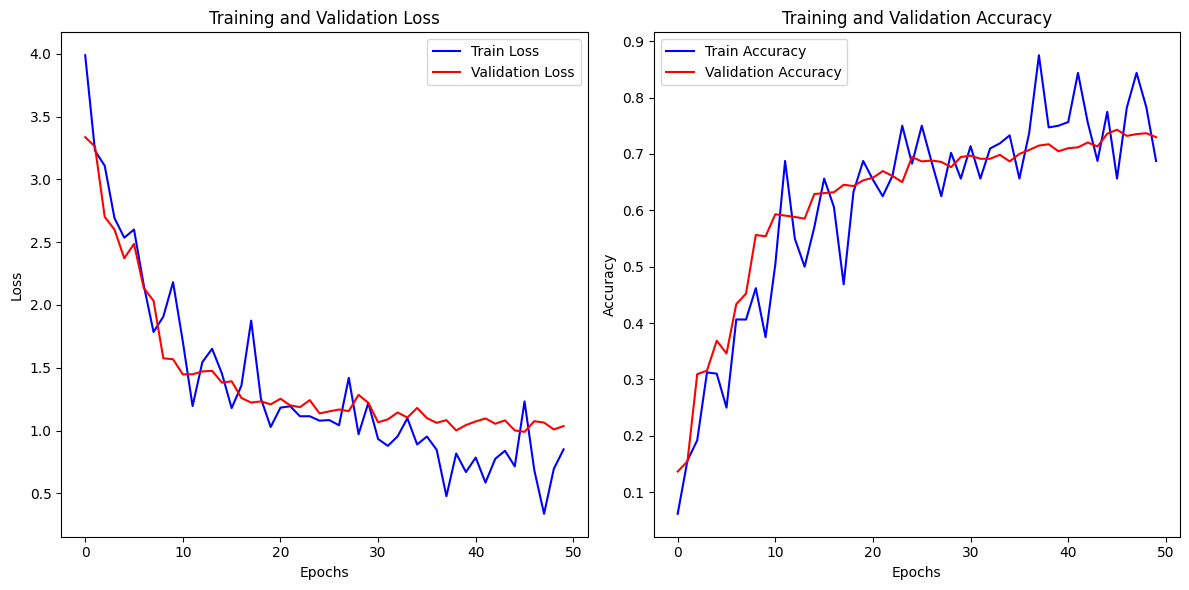

In [ ]:
# ======================
# 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ======================
# Графики обучения
def plot_training_history(history):
    plt.figure(figsize=(12, 6))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
# ======================
# 6. ВАЛИДАЦИЯ И ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ
# ======================
# Получение меток классов
class_indices = train_generator.class_indices
labels = list(class_indices.keys())

# Визуализация случайных предсказаний
def visualize_predictions(generator, num_samples=70):
    plt.figure(figsize=(20, 20))
    random_indices = random.sample(range(len(generator.filenames)), num_samples)

    for i, idx in enumerate(random_indices):
        img_path = os.path.join(DATA_DIR, generator.filenames[idx])
        img = load_img(img_path, target_size=IMAGE_SIZE)
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred_class = np.argmax(model.predict(img_array))
        true_class = generator.classes[idx]

        color = 'green' if pred_class == true_class else 'red'

        plt.subplot(10, 7, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Pred: {labels[pred_class]}\nTrue: {labels[true_class]}', color=color, fontsize=8)

    plt.tight_layout()
    plt.show()

visualize_predictions(val_generator)

# Матрица ошибок
def plot_confusion_matrix(generator):
    y_true = generator.classes
    y_pred = np.argmax(model.predict(generator), axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

plot_confusion_matrix(val_generator)

Output hidden; open in https://colab.research.google.com to view.